In [ ]:
!pip install aedat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 496.2/496.2 kB 38.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

import os
import shutil
import re
from pathlib import Path

Mounted at /content/drive/


In [ ]:
!git clone https://github.com/YmShan/SDTrack.git
!cd SDTrack/SDTrack-Event

Cloning into 'SDTrack'...
remote: Enumerating objects: 1551, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 1551 (delta 89), reused 47 (delta 47), pack-reused 1433 (from 3)
Receiving objects: 100% (1551/1551), 3.96 MiB | 12.08 MiB/s, done.
Resolving deltas: 100% (863/863), done.


In [ ]:
!pip install jpeg4py
!pip install lmdb
!pip install torchinfo
!pip install visdom

  Preparing metadata (setup.py) ... done
  Created wheel for jpeg4py: filename=jpeg4py-0.1.4-py3-none-any.whl size=8426 sha256=e5dff8531cb5a313d13f3743620c0ea62d536d8f6f2c1c3c8ff2b445dd7ab532
  Stored in directory: /root/.cache/pip/wheels/ab/a3/c5/3fce1e4f84180fa8362da30c3db4c719be956d49a0da49bd47
Successfully built jpeg4py
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 27.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for visdom: filename=visdom-0.2.4-py3-none-any.whl size=1408195 sha256=d3f528a0254080cddda771742ed1997ead8326d6890919a37e67f10b1d7c34ae
  Stored in directory: /root/.cache/pip/wheels/37/6c/38/64eeaa310e325aacda723e6df1f79ab5e9f31ba195264e04a8
Successfully built visdom


In [ ]:
#Put weights into correct folders

os.makedirs('/content/SDTrack/SDTrack-Event/pretrained_models', exist_ok=True)
os.makedirs('/content/SDTrack/SDTrack-Event/output/checkpoints/train/SDTrack/SDTrack-tiny-fe108', exist_ok=True)

shutil.copy(
    '/content/drive/MyDrive/Diploma_project/SDTrack_pretrained/SDTrack-tiny-1x4.pth',
    '/content/SDTrack/SDTrack-Event/pretrained_models/'
)

shutil.copy(
    '/content/drive/MyDrive/Diploma_project/SDTrack_pretrained/SDTrack_ep0100.pth.tar',
    '/content/SDTrack/SDTrack-Event/output/checkpoints/train/SDTrack/SDTrack-tiny-fe108/'
)



'/content/SDTrack/SDTrack-Event/output/checkpoints/train/SDTrack/SDTrack-tiny-fe108/SDTrack_ep0100.pth.tar'

# GTP

## aedat

In [ ]:
#Copy GTP script - aedat
shutil.copy(
    '/content/drive/MyDrive/Diploma_project/SDTrack_pretrained/aedat/GTP_FE108.py',
    '/content/SDTrack/SDTrack-Event/GTP_FE108.py'
)

'/content/SDTrack/SDTrack-Event/GTP_FE108.py'

In [ ]:
#Copy needed sequences - aedat

os.makedirs('/content/SDTrack/SDTrack-Event/data/test/airplane_mul222', exist_ok=True)
os.makedirs('/content/SDTrack/SDTrack-Event/data/train/', exist_ok=True)


shutil.copy(
    '/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/airplane_mul222/events.aedat4',
    '/content/SDTrack/SDTrack-Event/data/test/airplane_mul222'
)

shutil.copy(
    '/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/airplane_mul222/groundtruth_rect.txt',
    '/content/SDTrack/SDTrack-Event/data/test/airplane_mul222'
)

shutil.copytree(
    '/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/airplane_mul222/img',
    '/content/SDTrack/SDTrack-Event/data/test/airplane_mul222/img'
)

shutil.copy(
    '/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/pair.txt',
    '/content/SDTrack/SDTrack-Event/data/pair.txt'
)

#create test/test.txt
with open('/content/SDTrack/SDTrack-Event/data/test/test.txt', 'w') as f:
    f.write('airplane_mul222\n')

#Create empty train/test.txt and
os.makedirs('/content/SDTrack/SDTrack-Event/data/train', exist_ok=True)
with open('/content/SDTrack/SDTrack-Event/data/train/test.txt', 'w') as f:
    f.write('')


'/content/SDTrack/SDTrack-Event/data/pair.txt'

In [ ]:
#Create GTP frames - aedat

!python /content/SDTrack/SDTrack-Event/GTP_FE108.py \
    --trans_folder 0 \
    --source_dir /content/SDTrack/SDTrack-Event/data \
    --target_dir /content/SDTrack/SDTrack-Event/data \
    --stack_name inter1_stack_3008 \
    --s_test 0 \
    --e_test 1 \
    --stack_amount_1c2c 30 \
    --stack_amount_3c 30 \
    --decay_rate_3c 0.8

0 Writing airplane_mul222 events : 100% 9410493/9410493 [00:42<00:00, 221208.15it/s]


## csv

In [ ]:
# #Copy GTP script - csv
# shutil.copy(
#     '/content/drive/MyDrive/Diploma_project/SDTrack_pretrained/csv/GTP_FE108.py',
#     '/content/SDTrack/SDTrack-Event/GTP_FE108.py'
# )

'/content/SDTrack/SDTrack-Event/GTP_FE108.py'

In [ ]:
seq = 'ball_1:2hz'
initials = 'seya'

In [ ]:
!rm -rf '/content/SDTrack/SDTrack-Event/data/test/'

#Copy needed sequences - csv

os.makedirs(f'/content/SDTrack/SDTrack-Event/data/test/{seq}', exist_ok=True)
os.makedirs('/content/SDTrack/SDTrack-Event/data/train/', exist_ok=True)


# shutil.copy(
#     f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/flicker/{seq}/events.csv',
#     f'/content/SDTrack/SDTrack-Event/data/test/{seq}'
# )

shutil.copy(
    f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/flicker/{seq}/groundtruth_rect.txt',
    f'/content/SDTrack/SDTrack-Event/data/test/{seq}'
)

shutil.copytree(
    f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/flicker/{seq}/aps',
    f'/content/SDTrack/SDTrack-Event/data/test/{seq}/img'
)


shutil.copytree(
    f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/flicker/{seq}/inter1_stack_3008',
    f'/content/SDTrack/SDTrack-Event/data/test/{seq}/inter1_stack_3008'
)

#create test/test.txt
with open('/content/SDTrack/SDTrack-Event/data/test/test.txt', 'w') as f:
    f.write(f'{seq}\n')

#Create empty train/test.txt and
os.makedirs('/content/SDTrack/SDTrack-Event/data/train', exist_ok=True)
with open('/content/SDTrack/SDTrack-Event/data/train/test.txt', 'w') as f:
    f.write('')

In [ ]:
os.makedirs(f'/content/SDTrack/SDTrack-Event/data/test/airplane_mul222', exist_ok=True)
os.makedirs('/content/SDTrack/SDTrack-Event/data/train/', exist_ok=True)


shutil.copy(
    f'/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/airplane_mul222/groundtruth_rect.txt',
    f'/content/SDTrack/SDTrack-Event/data/test/airplane_mul222'
)

shutil.copytree(
    f'/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/airplane_mul222/aps',
    f'/content/SDTrack/SDTrack-Event/data/test/airplane_mul222/img'
)


shutil.copytree(
    f'/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/airplane_mul222/dvs',
    f'/content/SDTrack/SDTrack-Event/data/test/airplane_mul222/inter1_stack_3008'
)

'/content/SDTrack/SDTrack-Event/data/test/airplane_mul222/inter1_stack_3008'

In [ ]:
#create test/test.txt
with open('/content/SDTrack/SDTrack-Event/data/test/test.txt', 'w') as f:
    f.write(f'airplane_mul222\n')

#Create empty train/test.txt and
os.makedirs('/content/SDTrack/SDTrack-Event/data/train', exist_ok=True)
with open('/content/SDTrack/SDTrack-Event/data/train/test.txt', 'w') as f:
    f.write('')

In [ ]:
import os

base = f'/content/SDTrack/SDTrack-Event/data/test/airplane_mul222'

print(f"Folder exists: {os.path.exists(base)}")
print(f"Contents: {os.listdir(base)}")
print(f"events.csv: {os.path.exists(f'{base}/events.csv')}")
print(f"groundtruth_rect.txt: {os.path.exists(f'{base}/groundtruth_rect.txt')}")
print(f"img frames: {len(os.listdir(f'{base}/img'))}")

with open('/content/SDTrack/SDTrack-Event/data/test/test.txt') as f:
    print(f"test.txt: {f.read()}")

Folder exists: True
Contents: ['inter1_stack_3008', 'img', 'groundtruth_rect.txt']
events.csv: False
groundtruth_rect.txt: True
img frames: 2051
test.txt: airplane_mul222



In [ ]:
# #Create GTP frames - csv

# !python /content/SDTrack/SDTrack-Event/GTP_FE108.py \
#     --source_dir /content/SDTrack/SDTrack-Event/data \
#     --target_dir /content/SDTrack/SDTrack-Event/data \
#     --stack_name inter1_stack_3008 \
#     --stack_amount_1c2c 30 \
#     --stack_amount_3c 30 \
#     --decay_rate_3c 0.8

0 Writing skull_fl events: 100% 104071489/104071489 [06:59<00:00, 247948.84it/s]


In [ ]:
# Add empty lines in groundtruth_rect.txt

with open(f'/content/SDTrack/SDTrack-Event/data/test/{seq}/groundtruth_rect.txt', 'r') as f:
    first_bbox = f.readline().strip()

frame_count = len(os.listdir(f'/content/SDTrack/SDTrack-Event/data/test/{seq}/img'))

with open(f'/content/SDTrack/SDTrack-Event/data/test/{seq}/groundtruth_rect.txt', 'w') as f:
    f.write(first_bbox + '\n')
    for _ in range(frame_count - 1):
        f.write('0,0,0,0\n')

print(f"Written {frame_count} lines")

Written 214 lines


# Continue

In [ ]:
BASE = '/content/SDTrack/SDTrack-Event'

# === 1. Rewrite test/evaluation/local.py ===
Path(f'{BASE}/lib/test/evaluation/local.py').write_text(f'''from lib.test.evaluation.environment import EnvSettings

def local_env_settings():
    settings = EnvSettings()

    settings.prj_dir = '{BASE}'
    settings.network_path = '{BASE}/pretrained_models'
    settings.result_plot_path = '{BASE}/output/test/result_plots'
    settings.results_path = '{BASE}/output/test/tracking_results'
    settings.save_dir = '{BASE}/output'
    settings.segmentation_path = '{BASE}/output/test/segmentation_results'
    settings.eotb_path = '{BASE}/data/test'

    return settings
''')

# === 2. Update train/admin/local.py ===
train_local = Path(f'{BASE}/lib/train/admin/local.py')
train_local.write_text(
    train_local.read_text().replace('/data/users/xxx/SDTrack-Event', BASE)
)

# === 3. Remove cached bytecode ===
Path(f'{BASE}/lib/train/admin/__pycache__/local.cpython-312.pyc').unlink(missing_ok=True)

print("Done!")

Done!


In [ ]:
#Update eotbdataset.py

with open('/content/SDTrack/SDTrack-Event/lib/test/evaluation/eotbdataset.py', 'r') as f:
    content = f.read()

old = "    def _get_sequence_info_list(self):"
new = """    def _get_sequence_info_list(self):
        sequence_info_list = []
        for seq_name in sorted(os.listdir(self.base_path)):
            seq_path = os.path.join(self.base_path, seq_name)
            if not os.path.isdir(seq_path):
                continue
            anno_path = os.path.join(seq_path, 'groundtruth_rect.txt')
            if not os.path.exists(anno_path):
                continue
            stack_path = os.path.join(seq_path, 'inter1_stack_3008')
            if not os.path.exists(stack_path):
                continue
            end_frame = len(os.listdir(stack_path)) - 1
            sequence_info_list.append({
                'anno_path': f'{seq_name}/groundtruth_rect.txt',
                'endFrame': end_frame,
                'ext': 'png',
                'name': seq_name,
                'nz': 4,
                'object_class': 'object',
                'path': f'{seq_name}/inter1_stack_3008',
                'startFrame': 0
            })
        return sequence_info_list

    def _get_sequence_info_list_old(self):"""

content = content.replace("    def _get_sequence_info_list(self):", new)

with open('/content/SDTrack/SDTrack-Event/lib/test/evaluation/eotbdataset.py', 'w') as f:
    f.write(content)

print("Done!")

Done!


In [ ]:
#Update loader.py

with open('/content/SDTrack/SDTrack-Event/lib/train/data/loader.py', 'r') as f:
    content = f.read()

content = content.replace(
    'from torch._six import string_classes',
    'string_classes = str'
)

with open('/content/SDTrack/SDTrack-Event/lib/train/data/loader.py', 'w') as f:
    f.write(content)

print("Done!")

Done!


In [ ]:
# Add "weights_only=False"

with open('/content/SDTrack/SDTrack-Event/lib/models/SDTrack/SDTrack.py', 'r') as f:
    content = f.read()

content = content.replace(
    'torch.load(env_settings().pretrained_networks',
    'torch.load(env_settings().pretrained_networks'
).replace(
    ', map_location="cpu")',
    ', map_location="cpu", weights_only=False)'
)

with open('/content/SDTrack/SDTrack-Event/lib/models/SDTrack/SDTrack.py', 'w') as f:
    f.write(content)

with open('/content/SDTrack/SDTrack-Event/lib/test/tracker/SDTrack.py', 'r') as f:
    content = f.read()

content = content.replace(
    "torch.load(self.params.checkpoint, map_location='cpu')",
    "torch.load(self.params.checkpoint, map_location='cpu', weights_only=False)"
)

with open('/content/SDTrack/SDTrack-Event/lib/test/tracker/SDTrack.py', 'w') as f:
    f.write(content)

with open('/content/SDTrack/SDTrack-Event/lib/train/trainers/base_trainer.py', 'r') as f:
    content = f.read()

content = content.replace(
    "torch.load(checkpoint_path, map_location='cpu')",
    "torch.load(checkpoint_path, map_location='cpu', weights_only=False)"
)

with open('/content/SDTrack/SDTrack-Event/lib/train/trainers/base_trainer.py', 'w') as f:
    f.write(content)

print("Done!")

Done!


In [ ]:
import os

folder = "/content/SDTrack/SDTrack-Event/data/test/airplane_mul222/inter1_stack_3008"

for filename in os.listdir(folder):
    if filename.endswith(".png"):
        name = filename.replace(".png", "")   # "0001"
        new_name = f"{name}_1.png"            # "0001_1.png"
        os.rename(
            os.path.join(folder, filename),
            os.path.join(folder, new_name)
        )
        print(f"{filename} → {new_name}")

print("Done!")

0014.png → 0014_1.png
0648.png → 0648_1.png
1511.png → 1511_1.png
1993.png → 1993_1.png
1654.png → 1654_1.png
0752.png → 0752_1.png
1244.png → 1244_1.png
0668.png → 0668_1.png
1804.png → 1804_1.png
1836.png → 1836_1.png
0112.png → 0112_1.png
0858.png → 0858_1.png
0262.png → 0262_1.png
0058.png → 0058_1.png
0517.png → 0517_1.png
1316.png → 1316_1.png
2050.png → 2050_1.png
1500.png → 1500_1.png
0962.png → 0962_1.png
0492.png → 0492_1.png
0196.png → 0196_1.png
2028.png → 2028_1.png
0241.png → 0241_1.png
0685.png → 0685_1.png
1387.png → 1387_1.png
1634.png → 1634_1.png
0432.png → 0432_1.png
1718.png → 1718_1.png
0620.png → 0620_1.png
1809.png → 1809_1.png
1498.png → 1498_1.png
1521.png → 1521_1.png
0338.png → 0338_1.png
1405.png → 1405_1.png
1848.png → 1848_1.png
0413.png → 0413_1.png
0646.png → 0646_1.png
0111.png → 0111_1.png
0412.png → 0412_1.png
0565.png → 0565_1.png
0535.png → 0535_1.png
0546.png → 0546_1.png
0926.png → 0926_1.png
0495.png → 0495_1.png
0957.png → 0957_1.png
0419.png →

In [ ]:
%cd /content/SDTrack/SDTrack-Event

!python tracking/test.py SDTrack SDTrack-tiny-fe108 --dataset eotb --threads 8 --num_gpus 4

/content/SDTrack/SDTrack-Event
2026-04-13 16:03:01.736713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776096181.757395    8995 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776096181.764193    8995 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776096181.781755    8995 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776096181.781784    8995 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776096181.781787    8995 computation_placer

In [ ]:
pr_path = f'/content/SDTrack/SDTrack-Event/output/test/tracking_results/SDTrack/SDTrack-tiny-fe108/airplane_mul222.txt'
out_dir = f'/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/airplane_mul222/pr_sdtrack.txt'

shutil.copy(pr_path, out_dir)

'/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/airplane_mul222/pr_sdtrack.txt'

# Cycle

In [ ]:
from tqdm import tqdm

In [ ]:
# Cycle

sequences = ['flash_5s', 'flash_8s']

In [ ]:
for seq in tqdm(sequences):
    !rm -rf '/content/SDTrack/SDTrack-Event/data/test/'

    #Copy needed sequences - csv

    os.makedirs(f'/content/SDTrack/SDTrack-Event/data/test/{seq}', exist_ok=True)
    os.makedirs('/content/SDTrack/SDTrack-Event/data/train/', exist_ok=True)


    shutil.copy(
        f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/{seq}/events.csv',
        f'/content/SDTrack/SDTrack-Event/data/test/{seq}'
    )

    shutil.copy(
        f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/{seq}/groundtruth_rect.txt',
        f'/content/SDTrack/SDTrack-Event/data/test/{seq}'
    )

    shutil.copytree(
        f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/{seq}/aps',
        f'/content/SDTrack/SDTrack-Event/data/test/{seq}/img'
    )

    #create test/test.txt
    with open('/content/SDTrack/SDTrack-Event/data/test/test.txt', 'w') as f:
        f.write(f'{seq}\n')

    #Create empty train/test.txt and
    os.makedirs('/content/SDTrack/SDTrack-Event/data/train', exist_ok=True)
    with open('/content/SDTrack/SDTrack-Event/data/train/test.txt', 'w') as f:
        f.write('')


    !python /content/SDTrack/SDTrack-Event/GTP_FE108.py \
    --source_dir /content/SDTrack/SDTrack-Event/data \
    --target_dir /content/SDTrack/SDTrack-Event/data \
    --stack_name inter1_stack_3008 \
    --stack_amount_1c2c 30 \
    --stack_amount_3c 30 \
    --decay_rate_3c 0.8



    # Add empty lines in groundtruth_rect.txt
    with open(f'/content/SDTrack/SDTrack-Event/data/test/{seq}/groundtruth_rect.txt', 'r') as f:
        first_bbox = f.readline().strip()

    frame_count = len(os.listdir(f'/content/SDTrack/SDTrack-Event/data/test/{seq}/img'))

    with open(f'/content/SDTrack/SDTrack-Event/data/test/{seq}/groundtruth_rect.txt', 'w') as f:
        f.write(first_bbox + '\n')
        for _ in range(frame_count - 1):
            f.write('0,0,0,0\n')

    print(f"Written {frame_count} lines")


    %cd /content/SDTrack/SDTrack-Event
    !python tracking/test.py SDTrack SDTrack-tiny-fe108 --dataset eotb --threads 8 --num_gpus 4

    pr_path = f'/content/SDTrack/SDTrack-Event/output/test/tracking_results/SDTrack/SDTrack-tiny-fe108/{seq}.txt'
    out_dir = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/{seq}/pr_sdtrack.txt'

    shutil.copy(pr_path, out_dir)

  0%|          | 0/2 [00:00<?, ?it/s]

0 Writing flash_5s events: 100% 15217653/15217653 [01:01<00:00, 248602.45it/s]
Written 298 lines
/content/SDTrack/SDTrack-Event
2026-03-27 00:15:08.276089: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774570508.297338    7539 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774570508.304138    7539 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774570508.321441    7539 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774570508.321471    7539 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid

 50%|█████     | 1/2 [02:13<02:13, 133.27s/it]

0 Writing flash_8s events: 100% 10167194/10167194 [00:42<00:00, 239089.43it/s]
Written 304 lines
/content/SDTrack/SDTrack-Event
2026-03-27 00:16:58.785186: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774570618.805724    8881 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774570618.812463    8881 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774570618.830138    8881 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774570618.830162    8881 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid

100%|██████████| 2/2 [03:59<00:00, 119.71s/it]


# Cycle FE108

In [ ]:
from tqdm.notebook import tqdm

In [ ]:
sequences = sorted(os.listdir('/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test'))
sequences

['airplane_mul222',
 'bike222',
 'bike333',
 'bike_low',
 'bottle_mul222',
 'box_hdr',
 'box_low',
 'cow_mul222',
 'cup222',
 'cup_low',
 'dog',
 'dog_motion',
 'dove_motion',
 'fighter_mul',
 'giraffe222',
 'giraffe_low',
 'giraffe_motion',
 'ship',
 'ship_motion',
 'star',
 'star_mul',
 'star_mul222',
 'tank_low',
 'tower',
 'tower333',
 'truck',
 'truck_hdr',
 'whale_mul222']

In [ ]:
os.makedirs('/content/SDTrack/SDTrack-Event/data/train/', exist_ok=True)

for seq in tqdm(sequences):
    os.makedirs(f'/content/SDTrack/SDTrack-Event/data/test/{seq}', exist_ok=True)

    shutil.copy(
        f'/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/{seq}/events.aedat4',
        f'/content/SDTrack/SDTrack-Event/data/test/{seq}'
    )

    shutil.copy(
        f'/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/{seq}/groundtruth_rect.txt',
        f'/content/SDTrack/SDTrack-Event/data/test/{seq}'
    )

    shutil.copytree(
        f'/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/{seq}/img',
        f'/content/SDTrack/SDTrack-Event/data/test/{seq}/img'
    )

    shutil.copytree(
        f'/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/{seq}/inter1_stack_3008',
        f'/content/SDTrack/SDTrack-Event/data/test/{seq}/inter1_stack_3008'
    )

shutil.copy(
    '/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/pair.txt',
    '/content/SDTrack/SDTrack-Event/data/pair.txt'
)

  0%|          | 0/28 [00:00<?, ?it/s]

'/content/SDTrack/SDTrack-Event/data/pair.txt'

In [ ]:
# #create test/test.txt
# with open('/content/SDTrack/SDTrack-Event/data/test/test.txt', 'w') as f:
#     f.write('\n'.join(sequences))

# #Create empty train/test.txt and
# os.makedirs('/content/SDTrack/SDTrack-Event/data/train', exist_ok=True)
# with open('/content/SDTrack/SDTrack-Event/data/train/test.txt', 'w') as f:
#     f.write('')

In [ ]:
# #Create GTP frames - aedat

# !python /content/SDTrack/SDTrack-Event/GTP_FE108.py \
#     --trans_folder 0 \
#     --source_dir /content/SDTrack/SDTrack-Event/data \
#     --target_dir /content/SDTrack/SDTrack-Event/data \
#     --stack_name inter1_stack_3008 \
#     --s_test 0 \
#     --e_test 1 \
#     --stack_amount_1c2c 30 \
#     --stack_amount_3c 30 \
#     --decay_rate_3c 0.8

0 Writing airplane_mul222 events : 100% 9410493/9410493 [00:50<00:00, 186599.06it/s]
1 Writing bike222 events : 100% 41417287/41417287 [03:40<00:00, 188144.77it/s]
2 Writing bike333 events : 100% 74540985/74540985 [06:11<00:00, 200901.08it/s]
3 Writing bike_low events : 100% 12736380/12736380 [01:03<00:00, 201051.05it/s]
4 Writing bottle_mul222 events : 100% 6772659/6772659 [00:34<00:00, 193650.22it/s]
5 Writing box_hdr events : 100% 5820329/5820329 [00:32<00:00, 179837.86it/s]
6 Writing box_low events : 100% 4997318/4997318 [00:29<00:00, 171686.49it/s]
7 Writing cow_mul222 events : 100% 20001008/20001008 [01:39<00:00, 200105.97it/s]
8 Writing cup222 events : 100% 69773575/69773575 [05:48<00:00, 200216.08it/s]
9 Writing cup_low events : 100% 7167076/7167076 [00:39<00:00, 182118.09it/s]
10 Writing dog events : 100% 10818192/10818192 [00:53<00:00, 200880.08it/s]
11 Writing dog_motion events : 100% 95838812/95838812 [07:58<00:00, 200098.63it/s]
12 Writing dove_motion events : 100% 6107898

In [ ]:
%cd /content/SDTrack/SDTrack-Event

!python tracking/test.py SDTrack SDTrack-tiny-fe108 --dataset eotb --threads 8 --num_gpus 4

/content/SDTrack/SDTrack-Event
2026-04-11 21:59:37.152369: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775944777.173240  147118 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775944777.180135  147118 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775944777.197408  147118 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775944777.197435  147118 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775944777.197438  147118 computation_placer

## Metric

In [ ]:
def calc_metrics(gt, pr):
        min_len = min(len(gt), len(pr))
        gt = gt[:min_len]
        pr = pr[:min_len]

        gt_centers = gt[:, :2] + gt[:, 2:4] / 2
        pr_centers = pr[:, :2] + pr[:, 2:4] / 2
        distances  = np.sqrt(np.sum((gt_centers - pr_centers) ** 2, axis=1))
        precision  = np.mean(distances <= 20)

        ix1 = np.maximum(gt[:, 0], pr[:, 0])
        iy1 = np.maximum(gt[:, 1], pr[:, 1])
        ix2 = np.minimum(gt[:, 0] + gt[:, 2], pr[:, 0] + pr[:, 2])
        iy2 = np.minimum(gt[:, 1] + gt[:, 3], pr[:, 1] + pr[:, 3])

        inter_area = np.maximum(0, ix2 - ix1) * np.maximum(0, iy2 - iy1)
        union_area = gt[:, 2] * gt[:, 3] + pr[:, 2] * pr[:, 3] - inter_area
        iou        = inter_area / (union_area + 1e-10)
        success    = np.mean(iou > 0.5)



        return precision, success

In [ ]:
sequences = ['airplane_mul222']

In [ ]:
import numpy as np
import pandas as pd

rows = []
for seq in sequences:
    gt = f'/content/SDTrack/SDTrack-Event/data/test/{seq}/groundtruth_rect.txt'
    pr = f'/content/SDTrack/SDTrack-Event/output/test/tracking_results/SDTrack/SDTrack-tiny-fe108/{seq}.txt'

    gt_data     = np.loadtxt(gt, delimiter=',')
    pr_data  = np.loadtxt(pr)
    pr, sr = calc_metrics(gt_data, pr_data)

    rows.append({
    "sequence":    seq,
    "PR (SD)":     pr,
    "SR@0.5 (SD)": sr,
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

       sequence  PR (SD)  SR@0.5 (SD)
airplane_mul222     0.30         0.16


In [ ]:
import os
import shutil

for seq in sequences:
    src_path = f'/content/SDTrack/SDTrack-Event/output/test/tracking_results/SDTrack/SDTrack-tiny-fe108/{seq}.txt'
    dst_path = f'/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/{seq}/pr_sdtrack.txt'

    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    shutil.copy(src_path, dst_path)

    print(f'Copied: {src_path} -> {dst_path}')

Copied: /content/SDTrack/SDTrack-Event/output/test/tracking_results/SDTrack/SDTrack-tiny-fe108/airplane_mul222.txt -> /content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/airplane_mul222/pr_sdtrack.txt
Copied: /content/SDTrack/SDTrack-Event/output/test/tracking_results/SDTrack/SDTrack-tiny-fe108/bike222.txt -> /content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/bike222/pr_sdtrack.txt
Copied: /content/SDTrack/SDTrack-Event/output/test/tracking_results/SDTrack/SDTrack-tiny-fe108/bike333.txt -> /content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/bike333/pr_sdtrack.txt
Copied: /content/SDTrack/SDTrack-Event/output/test/tracking_results/SDTrack/SDTrack-tiny-fe108/bike_low.txt -> /content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/bike_low/pr_sdtrack.txt
Copied: /content/SDTrack/SDTrack-Event/output/test/tracking_results/SDTrack/SDTrack-tiny-fe108/bottle_mul222.txt -> /content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/bottle_mul222/pr_sd

# Unzip

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

seq = 'flash_1'
base = "/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya"

os.environ['SEQ'] = seq
os.environ['BASE'] = base

!unzip "$BASE/$SEQ.zip" -d "$BASE/$SEQ"

Archive:  /content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flash_1.zip
   creating: /content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flash_1/aps/
  inflating: /content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flash_1/aps/0098.png  
  inflating: /content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flash_1/aps/0039.png  
  inflating: /content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flash_1/aps/0199.png  
  inflating: /content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flash_1/aps/0125.png  
  inflating: /content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flash_1/aps/0106.png  
  inflating: /content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flash_1/aps/0042.png  
  inflating: /content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flash_1/aps/0110.png  
  inflating: /content/drive/MyDrive/Diploma

# Process GT

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
seq = 'banana_1:2hz'
gt_path = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/gt.txt'

df = pd.read_csv(
    gt_path,
    header=None,
    names=["frame", "id", "x", "y", "w", "h", "conf", "class", "visibility"]
)
df = df[df["id"] != 2].reset_index(drop=True)
df

,frame,id,x,y,w,h,conf,class,visibility
0,1,1,103.14,97.20,12.66,62.10,1,1,1.0
1,2,1,94.63,87.72,14.77,71.58,1,1,1.0
2,3,1,86.90,87.46,24.40,69.24,1,1,1.0
3,4,1,82.50,89.43,33.07,65.27,1,1,1.0
4,5,1,80.59,87.90,32.51,62.50,1,1,1.0
...,...,...,...,...,...,...,...,...,...
241,242,1,105.13,99.81,27.02,53.63,1,1,1.0
242,243,1,103.74,97.80,26.03,52.30,1,1,1.0
243,244,1,103.31,97.60,26.19,49.84,1,1,1.0
244,245,1,103.01,98.20,26.39,47.97,1,1,1.0


In [ ]:
# #make 0
# df.loc[df['frame'].between(7, 18), ['x', 'y', 'w', 'h']] = 0

In [ ]:
df_new = df[["x", "y", "w", "h"]]
df_new

,x,y,w,h
0,103.14,97.20,12.66,62.10
1,94.63,87.72,14.77,71.58
2,86.90,87.46,24.40,69.24
3,82.50,89.43,33.07,65.27
4,80.59,87.90,32.51,62.50
...,...,...,...,...
241,105.13,99.81,27.02,53.63
242,103.74,97.80,26.03,52.30
243,103.31,97.60,26.19,49.84
244,103.01,98.20,26.39,47.97


In [ ]:
new_gt_path = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/groundtruth_rect.txt'
df_new.to_csv(new_gt_path, sep=",", header=False, index=False)

# Create video

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import os
from tqdm.notebook import tqdm
import shutil

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
seq = 'flash_5s'

In [ ]:
len(os.listdir(f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/{seq}/dvs'))

381

In [ ]:
# For amt+sd

base = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/{seq}'
tmp = f'/tmp/{seq}'
os.makedirs(tmp, exist_ok=True)

def load_bboxes(path):
    bboxes = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                d = ',' if ',' in line else '\t'
                bboxes.append(list(map(float, line.split(d))))
    return bboxes

sdt = load_bboxes(f'{base}/pr_sdtrack.txt')
amt = load_bboxes(f'{base}/pr_amttrack.txt')
gt = load_bboxes(f'{base}/groundtruth_rect.txt')
aps_frames = sorted(os.listdir(f'{base}/aps'))
dvs_frames = sorted(os.listdir(f'{base}/dvs'))
n = min(len(aps_frames), len(dvs_frames), len(sdt), len(amt))

for i in tqdm(range(n)):
    aps = cv2.imread(f'{base}/aps/{aps_frames[i]}')
    dvs = cv2.imread(f'{base}/dvs/{dvs_frames[i]}')
    for fr in [aps, dvs]:
        x,y,w,h = [int(v) for v in sdt[i]]
        if any([x,y,w,h]): cv2.rectangle(fr,(x,y),(x+w,y+h),(255,0,0),2)
        x,y,w,h = [int(v) for v in amt[i]]
        if any([x,y,w,h]): cv2.rectangle(fr,(x,y),(x+w,y+h),(0,0,255),2)
        cv2.putText(fr,'SDTrack',(10,25),cv2.FONT_HERSHEY_SIMPLEX,0.8,(255,0,0),2)
        cv2.putText(fr,'AMTTrack',(10,55),cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,0,255),2)
    cv2.imwrite(f'{tmp}/{i:04d}.png', np.hstack([aps,dvs]))

!ffmpeg -y -framerate 30 -i {tmp}/%04d.png -c:v libx264 -pix_fmt yuv420p {base}/sd_amt2.mp4
shutil.rmtree(tmp)
print("Done!")

  0%|          | 0/314 [00:00<?, ?it/s]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
# for sd_amt_gt

base = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/{seq}'
tmp = f'/tmp/{seq}'
os.makedirs(tmp, exist_ok=True)

def load_bboxes(path):
    bboxes = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                d = ',' if ',' in line else '\t'
                bboxes.append(list(map(float, line.split(d))))
    return bboxes

sdt = load_bboxes(f'{base}/pr_sdtrack.txt')
amt = load_bboxes(f'{base}/pr_amttrack.txt')
gt  = load_bboxes(f'{base}/groundtruth_rect.txt')
aps_frames = sorted(os.listdir(f'{base}/aps_rgb'))
dvs_frames = sorted(os.listdir(f'{base}/dvs'))
n = min(len(aps_frames), len(dvs_frames), len(sdt), len(amt), len(gt))

for i in tqdm(range(n)):
    aps = cv2.imread(f'{base}/aps_rgb/{aps_frames[i]}')
    dvs = cv2.imread(f'{base}/dvs/{dvs_frames[i]}')
    for fr in [aps, dvs]:
        x,y,w,h = [int(v) for v in sdt[i]]
        if any([x,y,w,h]): cv2.rectangle(fr,(x,y),(x+w,y+h),(255,0,0),1)
        x,y,w,h = [int(v) for v in amt[i]]
        if any([x,y,w,h]): cv2.rectangle(fr,(x,y),(x+w,y+h),(0,0,255),1)
        x,y,w,h = [int(v) for v in gt[i]]
        if any([x,y,w,h]): cv2.rectangle(fr,(x,y),(x+w,y+h),(0,255,0),1)
        cv2.putText(fr,'SDTrack', (10,25),cv2.FONT_HERSHEY_SIMPLEX,0.4,(255,0,0),1)
        cv2.putText(fr,'AMTTrack',(10,55),cv2.FONT_HERSHEY_SIMPLEX,0.4,(0,0,255),1)
        cv2.putText(fr,'GT',      (10,40),cv2.FONT_HERSHEY_SIMPLEX,0.4,(0,255,0),1)
    cv2.imwrite(f'{tmp}/{i:04d}.png', np.hstack([aps,dvs]))

!ffmpeg -y -framerate 30 -i {tmp}/%04d.png -c:v libx264 -pix_fmt yuv420p {base}/sd_amt_gt.mp4
shutil.rmtree(tmp)
print("Done!")

  0%|          | 0/304 [00:00<?, ?it/s]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
# for GT
seq = 'ball_2hz'
base = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}'
tmp = f'/tmp/{seq}'
os.makedirs(tmp, exist_ok=True)

def load_bboxes(path):
    bboxes = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                d = ',' if ',' in line else '\t'
                bboxes.append(list(map(float, line.split(d))))
    return bboxes

gt = load_bboxes(f'{base}/groundtruth_rect.txt')
aps_frames = sorted(os.listdir(f'{base}/aps'))
dvs_frames = sorted(os.listdir(f'{base}/dvs'))
n = min(len(aps_frames), len(dvs_frames), len(gt))

for i in tqdm(range(n)):
    aps = cv2.imread(f'{base}/aps/{aps_frames[i]}')
    dvs = cv2.imread(f'{base}/dvs/{dvs_frames[i]}')

    # count active pixels on dvs using red/blue masks
    dvs_rgb = cv2.cvtColor(dvs, cv2.COLOR_BGR2RGB)
    r, g, b = dvs_rgb[:,:,0], dvs_rgb[:,:,1], dvs_rgb[:,:,2]
    red_mask  = (r == 220) & (g == 30) & (b == 30)
    blue_mask = (r == 30)  & (g == 30) & (b == 200)
    active_pixels = np.count_nonzero(red_mask) + np.count_nonzero(blue_mask)

    # draw GT bounding box on both frames
    x,y,w,h = [int(v) for v in gt[i]]
    for fr in [aps, dvs]:
        if any([x,y,w,h]): cv2.rectangle(fr,(x,y),(x+w,y+h),(0,255,0),2)

    # GT label and frame number — aps only (left frame)
    cv2.putText(aps, 'GT', (10,25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
    cv2.putText(aps, f'{i+1:04d}', (10, aps.shape[0]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)

    # active pixel count — bottom right corner of dvs
    label = f'active: {active_pixels}'
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    cv2.putText(dvs, label, (dvs.shape[1]-tw-10, dvs.shape[0]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)

    cv2.imwrite(f'{tmp}/{i:04d}.png', np.hstack([aps, dvs]))

!ffmpeg -y -framerate 30 -i {tmp}/%04d.png -c:v libx264 -pix_fmt yuv420p {base}/gt.mp4
shutil.rmtree(tmp)
print("Done!")

  0%|          | 0/204 [00:00<?, ?it/s]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## Cycle

In [ ]:
import os
from tqdm.notebook import tqdm
import cv2
import numpy as np
import shutil


sequences = ['flash_flicker', 'flash_1s', 'flash_3s', 'flash_5s']

In [ ]:
# for sd_amt

for seq in tqdm(sequences):
    base = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/{seq}'
    tmp = f'/tmp/{seq}'
    os.makedirs(tmp, exist_ok=True)

    def load_bboxes(path):
        bboxes = []
        with open(path) as f:
            for line in f:
                line = line.strip()
                if line:
                    d = ',' if ',' in line else '\t'
                    bboxes.append(list(map(float, line.split(d))))
        return bboxes

    sdt = load_bboxes(f'{base}/pr_sdtrack.txt')
    amt = load_bboxes(f'{base}/pr_amttrack.txt')
    aps_frames = sorted(os.listdir(f'{base}/aps'))
    dvs_frames = sorted(os.listdir(f'{base}/dvs'))
    n = min(len(aps_frames), len(dvs_frames), len(sdt), len(amt))

    for i in tqdm(range(n)):
        aps = cv2.imread(f'{base}/aps/{aps_frames[i]}')
        dvs = cv2.imread(f'{base}/dvs/{dvs_frames[i]}')
        for fr in [aps, dvs]:
            x,y,w,h = [int(v) for v in sdt[i]]
            if any([x,y,w,h]): cv2.rectangle(fr,(x,y),(x+w,y+h),(255,0,0),2)
            x,y,w,h = [int(v) for v in amt[i]]
            if any([x,y,w,h]): cv2.rectangle(fr,(x,y),(x+w,y+h),(0,0,255),2)
            cv2.putText(fr,'SDTrack',(10,25),cv2.FONT_HERSHEY_SIMPLEX,0.8,(255,0,0),2)
            cv2.putText(fr,'AMTTrack',(10,55),cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,0,255),2)
        cv2.imwrite(f'{tmp}/{i:04d}.png', np.hstack([aps,dvs]))

    !ffmpeg -y -framerate 30 -i {tmp}/%04d.png -c:v libx264 -pix_fmt yuv420p {base}/sd_amt.mp4
    shutil.rmtree(tmp)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/245 [00:00<?, ?it/s]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

  0%|          | 0/253 [00:00<?, ?it/s]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
# for sd_amt_gt

for seq in tqdm(sequences):
    base = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/{seq}'
    tmp = f'/tmp/{seq}'
    os.makedirs(tmp, exist_ok=True)

    sdt = load_bboxes(f'{base}/pr_sdtrack.txt')
    amt = load_bboxes(f'{base}/pr_amttrack.txt')
    gt  = load_bboxes(f'{base}/groundtruth_rect.txt')
    aps_frames = sorted(os.listdir(f'{base}/aps_rgb'))
    dvs_frames = sorted(os.listdir(f'{base}/dvs'))
    n = min(len(aps_frames), len(dvs_frames), len(sdt), len(amt), len(gt))

    for i in tqdm(range(n), desc=seq):
        aps = cv2.imread(f'{base}/aps_rgb/{aps_frames[i]}')
        dvs = cv2.imread(f'{base}/dvs/{dvs_frames[i]}')
        for fr in [aps, dvs]:
            x,y,w,h = [int(v) for v in sdt[i]]
            if any([x,y,w,h]): cv2.rectangle(fr,(x,y),(x+w,y+h),(255,0,0),1)
            x,y,w,h = [int(v) for v in amt[i]]
            if any([x,y,w,h]): cv2.rectangle(fr,(x,y),(x+w,y+h),(0,0,255),1)
            x,y,w,h = [int(v) for v in gt[i]]
            if any([x,y,w,h]): cv2.rectangle(fr,(x,y),(x+w,y+h),(0,255,0),1)
            cv2.putText(fr,'SDTrack', (10,25),cv2.FONT_HERSHEY_SIMPLEX,0.4,(255,0,0),1)
            cv2.putText(fr,'AMTTrack',(10,55),cv2.FONT_HERSHEY_SIMPLEX,0.4,(0,0,255),1)
            cv2.putText(fr,'GT',      (10,40),cv2.FONT_HERSHEY_SIMPLEX,0.4,(0,255,0),1)
        cv2.imwrite(f'{tmp}/{i:04d}.png', np.hstack([aps,dvs]))

    !ffmpeg -y -framerate 30 -i {tmp}/%04d.png -c:v libx264 -pix_fmt yuv420p {base}/sd_amt_gt.mp4
    shutil.rmtree(tmp)
    print(f"✓ Done: {seq}")


  0%|          | 0/4 [00:00<?, ?it/s]

flash_flicker:   0%|          | 0/230 [00:00<?, ?it/s]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

flash_1s:   0%|          | 0/219 [00:00<?, ?it/s]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

flash_3s:   0%|          | 0/314 [00:00<?, ?it/s]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

flash_5s:   0%|          | 0/298 [00:00<?, ?it/s]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

# Make RGB frames

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
seq = 'spinner_8hz'

In [ ]:
import cv2
import os

video_path = f"/content/drive/MyDrive/Diploma_project/own_videos/seya/flicker/{seq}.MOV"
output_dir = f"/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/aps_rgb"
os.makedirs(output_dir, exist_ok=True)

target_size = (346, 260)  # (width, height) — DVS size

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
print(f"FPS: {fps}")

i = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.resize(frame, target_size)
    cv2.imwrite(os.path.join(output_dir, f"{i+1:04d}.png"), frame)
    i += 1

cap.release()
print(f"Saved {i} frames")

FPS: 29.977628635346758
Saved 201 frames


In [ ]:
!rm -rf '/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker{seq}/aps_rgb'

In [ ]:
seq = 'spinner_8hz'

import os

print(len(os.listdir(f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/inter1_stack_3008')))
print(len(os.listdir(f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/aps_rgb')))
print(len(os.listdir(f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/aps')))
print(len(os.listdir(f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/dvs')))

201
201
201
201


# Metrics

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

import os
import numpy as np
import pandas as pd

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
sequences = sorted(os.listdir('/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker'))
sequences = [s for s in sequences if not s.endswith('.zip')]
sequences = sequences[10:15]
sequences

['spinner_1:2hz', 'spinner_1hz', 'spinner_2hz', 'spinner_4hz', 'spinner_8hz']

In [ ]:
def calc_metrics(gt, pr):
        min_len = min(len(gt), len(pr))
        gt = gt[:min_len]
        pr = pr[:min_len]

        gt_centers = gt[:, :2] + gt[:, 2:4] / 2
        pr_centers = pr[:, :2] + pr[:, 2:4] / 2
        distances  = np.sqrt(np.sum((gt_centers - pr_centers) ** 2, axis=1))
        precision  = np.mean(distances <= 20)

        ix1 = np.maximum(gt[:, 0], pr[:, 0])
        iy1 = np.maximum(gt[:, 1], pr[:, 1])
        ix2 = np.minimum(gt[:, 0] + gt[:, 2], pr[:, 0] + pr[:, 2])
        iy2 = np.minimum(gt[:, 1] + gt[:, 3], pr[:, 1] + pr[:, 3])

        inter_area = np.maximum(0, ix2 - ix1) * np.maximum(0, iy2 - iy1)
        union_area = gt[:, 2] * gt[:, 3] + pr[:, 2] * pr[:, 3] - inter_area
        iou        = inter_area / (union_area + 1e-10)
        success    = np.mean(iou > 0.5)



        return precision, success

In [ ]:
##Separate code

# import numpy as np

# gt = '/content/SDTrack/SDTrack-Event/data/test/airplane_mul222/groundtruth_rect.txt'
# pr = '/content/SDTrack/SDTrack-Event/output/test/tracking_results/SDTrack/SDTrack-tiny-fe108/airplane_mul222.txt'

# gt_data     = np.loadtxt(gt, delimiter=',')
# pr_data  = np.loadtxt(pr)

# pr, sr = calc_metrics(gt_data, pr_data)
# print(pr)
# print(sr)

0.9429546562652364
0.7181862506094588


In [ ]:
rows = []
pr_list_amt_gr = []
sr_list_amt_gr = []
pr_list_amt_rgb = []
sr_list_amt_rgb = []
pr_list_sd = []
sr_list_sd = []

for seq in sequences:
    path_gt     = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/groundtruth_rect.txt'
    path_pr_amt_gr = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/pr_amttrack.txt'
    path_pr_amt_rgb  = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/pr_amttrack_rgb.txt'
    path_pr_sd  = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/pr_sdtrack.txt'

    gt_data     = np.loadtxt(path_gt, delimiter=',')
    pr_data_amt_gr = np.loadtxt(path_pr_amt_gr)
    pr_data_amt_rgb = np.loadtxt(path_pr_amt_rgb)
    pr_data_sd  = np.loadtxt(path_pr_sd)

    pr_amt_gr, sr_amt_gr = calc_metrics(gt_data, pr_data_amt_gr)
    pr_amt_rgb, sr_amt_rgb = calc_metrics(gt_data, pr_data_amt_rgb)
    pr_sd,  sr_sd  = calc_metrics(gt_data, pr_data_sd)

    pr_list_amt_gr.append(pr_amt_gr)
    sr_list_amt_gr.append(sr_amt_gr)
    pr_list_amt_rgb.append(pr_amt_rgb)
    sr_list_amt_rgb.append(sr_amt_rgb)
    pr_list_sd.append(pr_sd)
    sr_list_sd.append(sr_sd)

    rows.append({
        "sequence":       seq,
        "PR (AMT_gr)":       pr_amt_gr,
        "SR@0.5 (AMT_gr)":   sr_amt_gr,
        "PR (AMT_rgb)":       pr_amt_rgb,
        "SR@0.5 (AMT_rgb)":   sr_amt_rgb,
        "PR (SD)":        pr_sd,
        "SR@0.5 (SD)":    sr_sd,
    })



df = pd.DataFrame(rows)

# df.loc[len(df)] = {
#     "sequence":     "Average",
#     "PR (AMT_gr)":     np.mean(pr_list_amt_gr),
#     "SR@0.5 (AMT_gr)": np.mean(sr_list_amt_gr),
#     "PR (AMT_rgb)":     np.mean(pr_list_amt_rgb),
#     "SR@0.5 (AMT_rgb)": np.mean(sr_list_amt_rgb),
#     "PR (SD)":      np.mean(pr_list_sd),
#     "SR@0.5 (SD)":  np.mean(sr_list_sd),
# }

print(df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

     sequence  PR (AMT_gr)  SR@0.5 (AMT_gr)  PR (AMT_rgb)  SR@0.5 (AMT_rgb)  PR (SD)  SR@0.5 (SD)
spinner_1:2hz         0.23             0.03          0.91              0.83     0.40         0.12
  spinner_1hz         0.10             0.00          0.47              0.42     0.25         0.06
  spinner_2hz         0.09             0.01          0.13              0.04     0.10         0.01
  spinner_4hz         0.09             0.00          0.11              0.00     0.02         0.00
  spinner_8hz         0.10             0.00          0.13              0.02     0.03         0.00


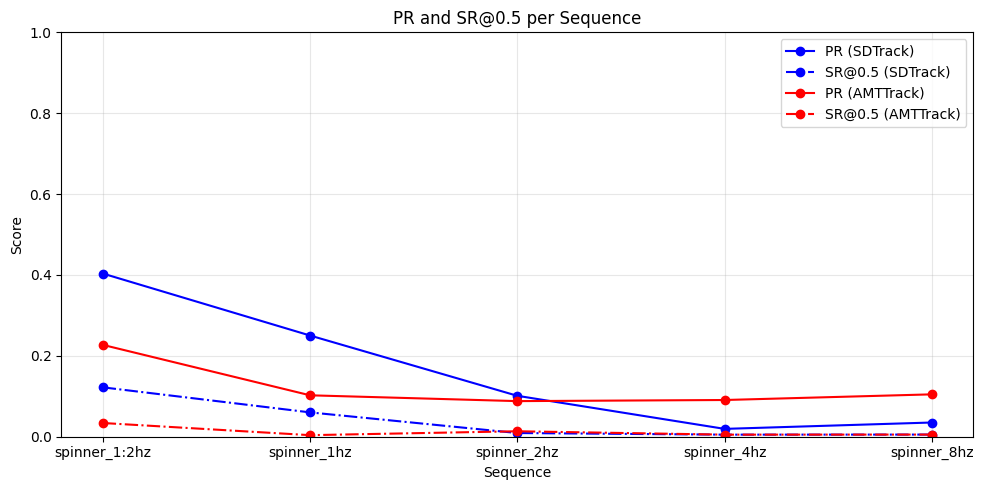

In [ ]:
import matplotlib.pyplot as plt

sequences_labels = ['spinner_1:2hz', 'spinner_1hz', 'spinner_2hz', 'spinner_4hz', 'spinner_8hz']

order = [sequences.index(s) for s in sequences_labels]

pr_sd_ordered  = [pr_list_sd[i]  for i in order]
sr_sd_ordered  = [sr_list_sd[i]  for i in order]
pr_amt_ordered = [pr_list_amt_gr[i] for i in order]
sr_amt_ordered = [sr_list_amt_gr[i] for i in order]

x = range(len(sequences_labels))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, pr_sd_ordered,  color='blue', linestyle='-',  marker='o', label='PR (SDTrack)')
ax.plot(x, sr_sd_ordered,  color='blue', linestyle='-.', marker='o', label='SR@0.5 (SDTrack)')
ax.plot(x, pr_amt_ordered, color='red',  linestyle='-',  marker='o', label='PR (AMTTrack)')
ax.plot(x, sr_amt_ordered, color='red',  linestyle='-.', marker='o', label='SR@0.5 (AMTTrack)')

ax.set_xticks(x)
ax.set_xticklabels(sequences_labels)
ax.set_ylim(0, 1)
ax.set_xlabel('Sequence')
ax.set_ylabel('Score')
ax.set_title('PR and SR@0.5 per Sequence')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Test rgb vs grayscale

In [ ]:
sequences = ['pen_1:2hz']

In [ ]:
rows = []
pr_list_gray = []
sr_list_gray = []
pr_list_rgb = []
sr_list_rgb = []
pr_list_gr3 = []
sr_list_gr3 = []

for seq in sequences:
    path_gt     = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/groundtruth_rect.txt'
    path_pr_gray = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/pr_amttrack.txt'
    path_pr_rgb  = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/pr_amttrack_rgb.txt'
    path_pr_gr3  = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/{seq}/pr_amttrack_gr3.txt'

    gt_data = np.loadtxt(path_gt, delimiter=',')
    pr_data_gray = np.loadtxt(path_pr_gray)
    pr_data_rgb  = np.loadtxt(path_pr_rgb)
    pr_data_gr3  = np.loadtxt(path_pr_gr3)

    pr_gray, sr_gray = calc_metrics(gt_data, pr_data_gray)
    pr_rgb,  sr_rgb  = calc_metrics(gt_data, pr_data_rgb)
    pr_gr3,  sr_gr3  = calc_metrics(gt_data, pr_data_gr3)


    pr_list_gray.append(pr_gray)
    sr_list_gray.append(sr_gray)
    pr_list_rgb.append(pr_rgb)
    sr_list_rgb.append(sr_rgb)
    pr_list_gr3.append(pr_gr3)
    sr_list_gr3.append(sr_gr3)

    rows.append({
        "sequence":       seq,
        "PR (gray)":       pr_gray,
        "SR@0.5 (gray)":   sr_gray,
        "PR (rgb)":        pr_rgb,
        "SR@0.5 (rgb)":    sr_rgb,
        "PR (gr3)":        pr_gr3,
        "SR@0.5 (gr3)":    sr_gr3,
    })



df = pd.DataFrame(rows)

# df.loc[len(df)] = {
#     "sequence":     "Average",
#     "PR (AMT)":     np.mean(pr_list_amt),
#     "SR@0.5 (AMT)": np.mean(sr_list_amt),
#     "PR (SD)":      np.mean(pr_list_sd),
#     "SR@0.5 (SD)":  np.mean(sr_list_sd),
# }

print(df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

 sequence  PR (gray)  SR@0.5 (gray)  PR (rgb)  SR@0.5 (rgb)  PR (gr3)  SR@0.5 (gr3)
pen_1:2hz       0.25           0.08      1.00          0.86      0.26          0.07


# Create video 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!pip install aedat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 496.2/496.2 kB 26.3 MB/s eta 0:00:00


In [ ]:
from aedat import Decoder

In [ ]:
path = '/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/dog/events.aedat4'

In [ ]:
decoder = Decoder(path)
packets = list(decoder)

In [ ]:
packets[0]

{'stream_id': 0,
 'events': array([(1601903420480265,  21,  29,  True),
        (1601903420480265,  45, 225,  True),
        (1601903420480274,  96,  32,  True), ...,
        (1601903420490243, 230,  48,  True),
        (1601903420490249,   3, 165,  True),
        (1601903420490249,  22, 232,  True)],
       dtype=[('t', '<u8'), ('x', '<u2'), ('y', '<u2'), (('on', 'p'), '?')])}

In [ ]:
import os

path = '/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test/dog/aps'
output = '/content/drive/MyDrive/Diploma_project/dog_output.mp4'

os.system(f'ffmpeg -framerate 30 -i "{path}/%04d.png" -c:v libx264 -pix_fmt yuv420p {output}')

0

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flash_1s/events.csv')
df

,t,x,y,p
0,350,283,69,0
1,350,285,65,1
2,350,295,77,1
3,350,284,69,0
4,350,292,69,1
...,...,...,...,...
31399579,7266667,242,101,0
31399580,7266667,242,103,0
31399581,7266667,223,131,1
31399582,7266667,226,127,1


# Make GTP frames

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

import os
import shutil
import re
from pathlib import Path

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
!git clone https://github.com/YmShan/SDTrack.git
!cd SDTrack/SDTrack-Event

Cloning into 'SDTrack'...
remote: Enumerating objects: 1548, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 1548 (delta 87), reused 47 (delta 47), pack-reused 1433 (from 3)
Receiving objects: 100% (1548/1548), 3.96 MiB | 36.89 MiB/s, done.
Resolving deltas: 100% (861/861), done.


In [ ]:
#Put weights into correct folders

os.makedirs('/content/SDTrack/SDTrack-Event/pretrained_models', exist_ok=True)
os.makedirs('/content/SDTrack/SDTrack-Event/output/checkpoints/train/SDTrack/SDTrack-tiny-fe108', exist_ok=True)

shutil.copy(
    '/content/drive/MyDrive/Diploma_project/SDTrack_pretrained/SDTrack-tiny-1x4.pth',
    '/content/SDTrack/SDTrack-Event/pretrained_models/'
)

shutil.copy(
    '/content/drive/MyDrive/Diploma_project/SDTrack_pretrained/SDTrack_ep0100.pth.tar',
    '/content/SDTrack/SDTrack-Event/output/checkpoints/train/SDTrack/SDTrack-tiny-fe108/'
)


'/content/SDTrack/SDTrack-Event/output/checkpoints/train/SDTrack/SDTrack-tiny-fe108/SDTrack_ep0100.pth.tar'

In [ ]:
#Copy GTP script - csv
shutil.copy(
    '/content/drive/MyDrive/Diploma_project/SDTrack_pretrained/csv/GTP_FE108.py',
    '/content/SDTrack/SDTrack-Event/GTP_FE108.py'
)

'/content/SDTrack/SDTrack-Event/GTP_FE108.py'

In [ ]:
seq = 'ball_1hz'
initials = 'seya'

In [ ]:
!rm -rf '/content/SDTrack/SDTrack-Event/data/test/'

#Copy needed sequences - csv

os.makedirs(f'/content/SDTrack/SDTrack-Event/data/test/{seq}', exist_ok=True)
os.makedirs('/content/SDTrack/SDTrack-Event/data/train/', exist_ok=True)


shutil.copy(
    f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/flicker/{seq}/events.csv',
    f'/content/SDTrack/SDTrack-Event/data/test/{seq}'
)


shutil.copytree(
    f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/flicker/{seq}/aps',
    f'/content/SDTrack/SDTrack-Event/data/test/{seq}/img'
)


#create test/test.txt
with open('/content/SDTrack/SDTrack-Event/data/test/test.txt', 'w') as f:
    f.write(f'{seq}\n')

#Create empty train/test.txt and
os.makedirs('/content/SDTrack/SDTrack-Event/data/train', exist_ok=True)
with open('/content/SDTrack/SDTrack-Event/data/train/test.txt', 'w') as f:
    f.write('')

In [ ]:
import os

base = f'/content/SDTrack/SDTrack-Event/data/test/{seq}'

print(f"Folder exists: {os.path.exists(base)}")
print(f"Contents: {os.listdir(base)}")
print(f"events.csv: {os.path.exists(f'{base}/events.csv')}")
print(f"groundtruth_rect.txt: {os.path.exists(f'{base}/groundtruth_rect.txt')}")
print(f"img frames: {len(os.listdir(f'{base}/img'))}")

with open('/content/SDTrack/SDTrack-Event/data/test/test.txt') as f:
    print(f"test.txt: {f.read()}")

Folder exists: True
Contents: ['events.csv', 'img']
events.csv: True
groundtruth_rect.txt: False
img frames: 202
test.txt: ball_1hz



In [ ]:
#Create GTP frames - csv

!python /content/SDTrack/SDTrack-Event/GTP_FE108.py \
    --source_dir /content/SDTrack/SDTrack-Event/data \
    --target_dir /content/SDTrack/SDTrack-Event/data \
    --stack_name inter1_stack_3008 \
    --stack_amount_1c2c 30 \
    --stack_amount_3c 30 \
    --decay_rate_3c 0.8

0 Writing ball_1hz events: 100% 27771576/27771576 [02:18<00:00, 200902.16it/s]


In [ ]:
shutil.copytree(
    f'/content/SDTrack/SDTrack-Event/data/test/{seq}/inter1_stack_3008',
    f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/flicker/{seq}/inter1_stack_3008'
)

'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker/ball_1hz/inter1_stack_3008'

## Create GTP

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')


!git clone https://github.com/YmShan/SDTrack.git
!cd SDTrack/SDTrack-Event



import os
import shutil
import re
from pathlib import Path
from tqdm.notebook import tqdm
import time


#Copy GTP script - csv
shutil.copy(
    '/content/drive/MyDrive/Diploma_project/SDTrack_pretrained/csv/GTP_FE108_csv.py',
    '/content/SDTrack/SDTrack-Event/GTP_FE108.py'
)

Mounted at /content/drive/
Cloning into 'SDTrack'...
remote: Enumerating objects: 1551, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 1551 (delta 89), reused 47 (delta 47), pack-reused 1433 (from 3)
Receiving objects: 100% (1551/1551), 3.96 MiB | 12.01 MiB/s, done.
Resolving deltas: 100% (863/863), done.


'/content/SDTrack/SDTrack-Event/GTP_FE108.py'

In [ ]:
initials = 'seya'
sequences = ['ruler', 'spinner']

for seq in tqdm(sequences):
    csvs = ['events_1.csv', 'events_2.csv', 'events_3.csv', 'events_4.csv', 'events_5.csv']

    for i, csv in tqdm(enumerate(csvs)):

        os.makedirs(f'/content/SDTrack/SDTrack-Event/data/test/{seq}', exist_ok=True)
        os.makedirs('/content/SDTrack/SDTrack-Event/data/train/', exist_ok=True)

        shutil.copy(
            f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/clean/{seq}/augmented2/{csv}',
            f'/content/SDTrack/SDTrack-Event/data/test/{seq}/events.csv')

        shutil.copytree(
            f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/clean/{seq}/aps',
            f'/content/SDTrack/SDTrack-Event/data/test/{seq}/img')


        with open('/content/SDTrack/SDTrack-Event/data/test/test.txt', 'w') as f:
            f.write(f'{seq}\n')

        #Create empty train/test.txt and
        os.makedirs('/content/SDTrack/SDTrack-Event/data/train', exist_ok=True)
        with open('/content/SDTrack/SDTrack-Event/data/train/test.txt', 'w') as f:
            f.write('')

        !python /content/SDTrack/SDTrack-Event/GTP_FE108.py \
        --target_dir /content/SDTrack/SDTrack-Event/data \
        --stack_name inter1_stack_3008 \
        --T_num 1 \
        --stack_amount_1c2c 30 \
        --stack_amount_3c 30 \
        --decay_rate_3c 0.8

        src_dir = f'/content/SDTrack/SDTrack-Event/data/test/{seq}/inter1_stack_3008'
        dst_dir = f'/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/clean/{seq}/augmented2/gtp_{i+1}'
        if os.path.exists(src_dir) and not os.path.exists(dst_dir):
            shutil.copytree(src_dir, dst_dir)

        os.system(f'rm -rf /content/SDTrack/SDTrack-Event/data/test/{seq}')
        time.sleep(5)

  0%|          | 0/2 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0 Writing ruler: 100% 85885015/85885015 [08:08<00:00, 175928.56it/s]
0 Writing ruler: 100% 78285343/78285343 [07:25<00:00, 175798.12it/s]
0 Writing ruler: 100% 86493882/86493882 [08:26<00:00, 170787.70it/s]
0 Writing ruler: 100% 80560957/80560957 [07:54<00:00, 169914.33it/s]
0 Writing ruler: 100% 78009273/78009273 [07:36<00:00, 170903.09it/s]


0it [00:00, ?it/s]

0 Writing spinner: 100% 84740129/84740129 [08:00<00:00, 176498.57it/s]
0 Writing spinner: 100% 79227057/79227057 [07:34<00:00, 174212.13it/s]
0 Writing spinner: 100% 83155185/83155185 [08:04<00:00, 171604.15it/s]
0 Writing spinner: 100% 78411501/78411501 [07:44<00:00, 168827.62it/s]
0 Writing spinner: 100% 76136398/76136398 [07:12<00:00, 176052.54it/s]


# Create events

In [ ]:
%pip install numba -q
%pip install engineering-notation -q
%pip install opencv-contrib-python -q
%pip install argcomplete -q
%pip install dv-processing -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.2/24.2 MB 32.7 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/SensorsINI/v2e
%cd /content/v2e
#!python setup.py develop
%pip install .
!mkdir input
%cd /content/
%pwd

Cloning into 'v2e'...
remote: Enumerating objects: 3227, done.
remote: Counting objects: 100% (1204/1204), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 3227 (delta 1157), reused 1103 (delta 1103), pack-reused 2023 (from 1)
Receiving objects: 100% (3227/3227), 34.25 MiB | 20.01 MiB/s, done.
Resolving deltas: 100% (2391/2391), done.
/content/v2e
Processing /content/v2e
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.7/92.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 6.7 MB/s eta 0:00:00
  Created wheel for v2e: filename=v2e-1.5.1-py3-none-any.whl size=116998 sha256=653e4908405488f8f5f5d99505a1ec3af36e85702fcd66e26b31266bfeb889c1
  Stored in directory: /tmp/pip-ephem-wheel-cache-8xjpi1p9/wheels/f4/f3/51/80837a929df608ceb06a5ecdb5f272f60a25522cfd8be8913d
Successfully built v2e
/content


'/content'

In [ ]:
import gdown
import os
from tqdm.notebook import tqdm
import shutil
import cv2
import pandas as pd
import numpy as np
from PIL import Image
import h5py
import pandas as pd
import subprocess


os.makedirs('/content/v2e/input/', exist_ok=True)

url = 'https://drive.google.com/uc?id=1ETID_4xqLpRBrRo1aOT7Yphs3QqWR_fx'
output = '/content/v2e/input/SuperSloMo39.ckpt'
gdown.download(url, output, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1ETID_4xqLpRBrRo1aOT7Yphs3QqWR_fx
From (redirected): https://drive.google.com/uc?id=1ETID_4xqLpRBrRo1aOT7Yphs3QqWR_fx&confirm=t&uuid=ac77e81e-73d1-42a3-b27b-5dbda82aa04f
To: /content/v2e/input/SuperSloMo39.ckpt
100%|██████████| 158M/158M [00:01<00:00, 112MB/s]


'/content/v2e/input/SuperSloMo39.ckpt'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
initials = 'seya'

sequences = ['cleaner_1:2hz', 'cleaner_1hz', 'cleaner_2hz', 'knife_1:2hz', 'knife_1hz', 'knife_2hz',
             'longus_1:2hz', 'longus_1hz', 'longus_2hz', 'nonstop_1:2hz',
             'nonstop_1hz', 'nonstop_2hz', 'rexona_1:2hz', 'rexona_1hz', 'rexona_2hz']

In [ ]:
# if RAM overloaded

def create_frames_from_csv(csv_path, output_dir, aps_dir, width=346, height=260):
    os.makedirs(output_dir, exist_ok=True)

    # Get sorted list of APS frames to match DVS frame count
    aps_frames = sorted([
        f for f in os.listdir(aps_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])
    num_frames = len(aps_frames)
    if num_frames == 0:
        raise ValueError(f"No frames found in '{aps_dir}'.")
    print(f"APS frames found: {num_frames}")

    # Read only first row to get t_start (avoids loading entire CSV)
    first_chunk = pd.read_csv(csv_path, nrows=1)
    t_start = first_chunk['t'].iloc[0]

    # Read only last row to get t_end (avoids loading entire CSV)
    with open(csv_path, 'rb') as f:
        f.seek(-2, 2)
        while f.read(1) != b'\n':
            f.seek(-2, 1)
        last_line = f.readline().decode()
    t_end = float(last_line.split(',')[0])

    # Create evenly spaced time boundaries for each frame
    frame_boundaries = np.linspace(t_start, t_end, num_frames + 1)

    # Pre-allocate accumulation frames (~30 MB total, safe)
    frames = [np.zeros((height, width), dtype=np.int16) for _ in range(num_frames)]

    print("Reading events and building frames (chunked)...")
    chunk_size = 5_000_000  # 5M rows per chunk (~160 MB RAM per iteration)

    for chunk in tqdm(pd.read_csv(csv_path, chunksize=chunk_size),
                      desc="Processing chunks"):
        t = chunk['t'].to_numpy()
        x = chunk['x'].to_numpy()
        y = chunk['y'].to_numpy()
        p = chunk['p'].to_numpy()

        # Assign each event to its corresponding frame index
        frame_idxs = np.searchsorted(frame_boundaries[1:], t, side='right')
        frame_idxs = np.clip(frame_idxs, 0, num_frames - 1)

        # Filter out out-of-bounds pixel coordinates
        valid = (x >= 0) & (x < width) & (y >= 0) & (y < height)
        x = x[valid]
        y = y[valid]
        p = p[valid]
        frame_idxs = frame_idxs[valid]

        # Convert polarity: ON=+1, OFF=-1
        vals = np.where(p, 1, -1).astype(np.int16)

        # Accumulate events into their respective frames
        for fi in np.unique(frame_idxs):
            mask = frame_idxs == fi
            np.add.at(frames[fi], (y[mask], x[mask]), vals[mask])

    # Render and save DVS frames as PNG images
    print("Saving DVS frames...")
    for frame_idx, frame in enumerate(tqdm(frames, desc="Saving DVS frames")):
        img = np.full((height, width, 3), 255, dtype=np.uint8)
        img[frame > 0] = (220, 30, 30)
        img[frame < 0] = (30, 30, 200)
        file_name = aps_frames[frame_idx]
        Image.fromarray(img).save(os.path.join(output_dir, file_name))


for seq in tqdm(sequences):
    %cd /content
    !rm -rf '/content/v2e-output'

    os.makedirs('/content/video', exist_ok=True)
    shutil.copy(f'/content/drive/MyDrive/Diploma_project/own_videos/{initials}/flicker/{seq}.MOV', '/content/video')

    video_path = f"/content/video/{seq}.MOV"

    if video_path != "" and os.path.isfile(video_path):
        display("The chosen video file: {}".format(video_path))
    else:
        print("The file path is empty or invalid, choose a file")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_sec = frame_count / fps if fps > 0 else 0

    print(f"FPS: {fps}")
    print(f"Frame count: {frame_count}")
    print(f"Duration: {duration_sec:.2f} sec")

    cap.release()

    output_folder = "/content/v2e-output"
    overwrite = True
    unique_output_folder = False
    out_filename = "events.h5"
    davis_output = True
    skip_video_output = False
    dvs_exposure = f"duration {1/fps:.3f}"
    output_mode = "dvs346"
    input_frame_rate = 30
    input_slowmotion_factor = 1
    disable_slomo = False
    timestamp_resolution = 0.001
    auto_timestamp_resolution = True
    slomo_model = "/content/v2e/input/SuperSloMo39.ckpt"
    condition = "Clean"
    thres = 0.2
    sigma = 0.03
    cutoff_hz = 200
    leak_rate_hz = 5.18
    shot_noise_rate_hz = 2.716

    if condition == "Clean":
        thres = 0.2
        sigma = 0.02
        cutoff_hz = 0
        leak_rate_hz = 0
        shot_noise_rate_hz = 0
    elif condition == "Noisy":
        thres = 0.2
        sigma_thres = 0.05
        cutoff_hz = 30
        leak_rate_hz = 0.1
        shot_noise_rate_hz = 5

    v2e_command = ["v2e"]
    v2e_command += ["-i", video_path]
    v2e_command += ["-o", output_folder]

    if overwrite:
        v2e_command.append("--overwrite")

    v2e_command += ["--unique_output_folder", "{}".format(unique_output_folder).lower()]

    if davis_output:
        v2e_command += ["--davis_output"]
    v2e_command += ["--dvs_h5", out_filename]
    v2e_command += ["--dvs_aedat2", "None"]
    v2e_command += ["--dvs_text", "None"]
    v2e_command += ["--no_preview"]

    if skip_video_output:
        v2e_command += ["--skip_video_output"]
    else:
        dvs_exposure = f"duration {1/input_frame_rate:.6f}"
        v2e_command += ["--dvs_exposure", dvs_exposure]

    v2e_command += ["--input_frame_rate", "{}".format(input_frame_rate)]
    v2e_command += ["--input_slowmotion_factor", "{}".format(input_slowmotion_factor)]

    if disable_slomo:
        v2e_command += ["--disable_slomo"]
        v2e_command += ["--auto_timestamp_resolution", "false"]
    else:
        v2e_command += ["--slomo_model", slomo_model]
        if auto_timestamp_resolution:
            v2e_command += ["--auto_timestamp_resolution", "{}".format(auto_timestamp_resolution).lower()]
        else:
            v2e_command += ["--timestamp_resolution", "{}".format(timestamp_resolution)]

    v2e_command += ["--pos_thres", "{}".format(thres)]
    v2e_command += ["--neg_thres", "{}".format(thres)]
    v2e_command += ["--sigma_thres", "{}".format(sigma)]
    v2e_command += ["--cutoff_hz", "{}".format(cutoff_hz)]
    v2e_command += ["--leak_rate_hz", "{}".format(leak_rate_hz)]
    v2e_command += ["--shot_noise_rate_hz", "{}".format(shot_noise_rate_hz)]
    v2e_command += [f"--{output_mode}"]

    final_v2e_command = " ".join(v2e_command)
    print("The Final v2e command:")
    display(final_v2e_command)

    !$final_v2e_command

    # Convert h5 events to csv (chunked, memory-safe)
    h5_path  = "/content/v2e-output/events.h5"
    csv_path = "/content/v2e-output/events.csv"
    chunk_size = 5_000_000  # 5M rows per chunk (~160 MB RAM)

    with h5py.File(h5_path, "r") as f:
        total = f["events"].shape[0]
        print(f"Total events: {total:,}")
        first = True
        for start in range(0, total, chunk_size):
            chunk = f["events"][start:start + chunk_size]
            df = pd.DataFrame(chunk, columns=["t", "x", "y", "p"])
            df.to_csv(csv_path, mode='w' if first else 'a',
                      index=False, header=first)
            first = False
            print(f"  Written {min(start + chunk_size, total):,}/{total:,}")

    print(f"Saved: {csv_path}")

    # Extract APS frames
    video_path = "/content/v2e-output/video_orig.avi"
    output_dir = "/content/v2e-output/aps"
    os.makedirs(output_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_path = os.path.join(output_dir, f"{frame_count + 1:04d}.png")
        cv2.imwrite(frame_path, frame)
        frame_count += 1

    cap.release()
    print("Detected FPS:", fps)
    print("Saved frames:", frame_count)
    print("Output folder:", output_dir)

    # Generate DVS frames (chunked, memory-safe)
    create_frames_from_csv(
        csv_path="/content/v2e-output/events.csv",
        output_dir="/content/v2e-output/dvs",
        aps_dir="/content/v2e-output/aps",
        width=346,
        height=260
    )

    !ffmpeg -y -framerate 30 -i /content/v2e-output/aps/%04d.png -framerate 30 -i /content/v2e-output/dvs/%04d.png -filter_complex hstack -c:v libx264 -pix_fmt yuv420p /content/v2e-output/aps_dvs.mp4

    !rm -rf '/content/v2e-output/dvs-video-frame_times.txt'
    !rm -rf '/content/v2e-output/dvs-video.avi'
    !rm -rf '/content/v2e-output/events.h5'
    !rm -rf '/content/v2e-output/v2e-args.txt'
    !rm -rf '/content/v2e-output/video_orig.avi'
    !rm -rf '/content/v2e-output/video_slomo.avi'

    %cd /content/v2e-output
    !zip -r /content/{seq}.zip .

    shutil.copy(
        f"/content/{seq}.zip",
        f"/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/flicker/{seq}.zip"
    )

    base = f"/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/{initials}/flicker"
    os.environ['SEQ'] = seq
    os.environ['BASE'] = base
    !unzip "$BASE/$SEQ.zip" -d "$BASE/$SEQ"

    print(f"✓ Done: {seq}")

  0%|          | 0/4 [00:00<?, ?it/s]

/content


'The chosen video file: /content/video/nonstop_2hz.MOV'

FPS: 29.177718832891248
Frame count: 220
Duration: 7.54 sec
The Final v2e command:


'v2e -i /content/video/nonstop_2hz.MOV -o /content/v2e-output --overwrite --unique_output_folder false --davis_output --dvs_h5 events.h5 --dvs_aedat2 None --dvs_text None --no_preview --dvs_exposure duration 0.033333 --input_frame_rate 30 --input_slowmotion_factor 1 --slomo_model /content/v2e/input/SuperSloMo39.ckpt --auto_timestamp_resolution true --pos_thres 0.2 --neg_thres 0.2 --sigma_thres 0.02 --cutoff_hz 0 --leak_rate_hz 0 --shot_noise_rate_hz 0 --dvs346'

...

INFO:v2e:torch device is cuda
INFO:v2e:No module named 'gooey': Gooey GUI builder not available, will use command line arguments.
Install with 'pip install Gooey if you want a no-arg GUI to invoke v2e'. See README
INFO:v2e:name 'Gooey' is not defined: Gooey package GUI not available, using command line arguments. 
You can try to install with "pip install Gooey"
INFO:v2ecore.v2e_utils:using output folder /content/v2e-output
INFO:v2e:output_in_place==False so made output_folder=/content/v2e-output
INFO:v2ecore.v2e_args:
*** arguments:
auto_timestamp_resolution:	True
avi_frame_rate:	30
batch_size:	8
crop:	None
cs_lambda_pixels:	None
cs_tau_p_ms:	None
cutoff_hz:	0.0
ddd_output:	False
disable_slomo:	False
dvs1024:	False
dvs128:	False
dvs240:	False
dvs346:	True
dvs640:	False
dvs_aedat2:	None
dvs_aedat4:	None
dvs_emulator_seed:	0
dvs_exposure:	['duration', '0.033333']
dvs_h5:	events.h5
dvs_params:	None
dvs_text:	None
dvs_vid:	dvs-video.avi
dvs_vid_full_scale:	2
hdr:	False
input:	/content/vide

Processing chunks: 0it [00:00, ?it/s]

Saving DVS frames...


Saving DVS frames:   0%|          | 0/222 [00:00<?, ?it/s]

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab